In [2]:
import numpy as np
import matplotlib.pyplot as  plt
from sklearn.model_selection import train_test_split,KFold

In [3]:
np.random.seed(0)

In [4]:
dogs_whisker_length = np.random.normal(loc=5,scale=1, size =10)
dogs_earflapiness_index = np.random.normal(loc= 8, scale=1,size=10)

In [5]:
cats_whisker_length = np.random.normal(loc=8,scale=1, size =10)
cats_earflapiness_index = np.random.normal(loc=5, scale=1,size=10)

In [12]:
dogs_data=np.vstack((dogs_whisker_length,dogs_earflapiness_index)).T
cats_data=np.vstack((cats_whisker_length,cats_earflapiness_index)).T
data=np.vstack((dogs_data,cats_data))
labels=np.hstack((np.zeros(len(dogs_data)),np.ones(len(cats_data))))

In [46]:
X_train,X_test,y_train,y_test=train_test_split(data,labels,test_size=0.2,random_state=42)

In [47]:
X_test

array([[6.76405235, 8.14404357],
       [7.81281615, 6.20237985],
       [6.54563433, 5.15634897],
       [5.40015721, 9.45427351]])

In [48]:
X_train

array([[ 4.89678115,  8.3130677 ],
       [ 4.02272212,  8.33367433],
       [ 8.6536186 ,  5.37816252],
       [ 7.2408932 ,  8.12167502],
       [ 9.53277921,  4.61267318],
       [ 8.04575852,  6.23029068],
       [ 7.25783498,  3.01920353],
       [ 5.97873798,  8.76103773],
       [ 5.4105985 ,  7.14590426],
       [ 9.46935877,  4.69769725],
       [ 6.86755799,  8.44386323],
       [ 8.8644362 ,  4.11221425],
       [ 4.84864279,  7.79484174],
       [ 5.44701018,  5.15494743],
       [10.26975462,  4.65208785],
       [ 5.95008842,  9.49407907]])

In [16]:
labels

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

<function matplotlib.pyplot.show(close=None, block=None)>

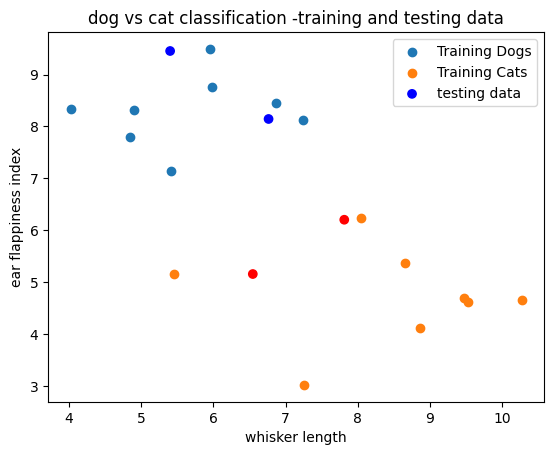

In [49]:
plt.scatter(X_train[y_train == 0] [:,0],X_train[y_train == 0] [:,1], label='Training Dogs')
plt.scatter(X_train[y_train == 1] [:,0],X_train[y_train == 1] [:,1] ,label='Training Cats')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='bwr' ,label='testing data')
plt.xlabel('whisker length')
plt.ylabel('ear flappiness index')  
plt.title('dog vs cat classification -training and testing data')
plt.legend()
plt.show    


In [50]:
def random_lc(data_dogs, data_cats, k, d):
    best_error = float('inf')  # Initialize with a high value
    best_theta = None
    best_theta0 = None

    for _ in range(k):
        theta = np.random.normal(size=d)
        theta0 = np.random.normal()
        
        error = compute_error(data_dogs, data_cats, theta, theta0)

        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0

    return best_theta, best_theta0, best_error

In [51]:
def compute_error(data_dogs,data_cats,theta,theta0):
    error=0

    for x_dog in data_dogs :
        if np.dot(theta,x_dog)+theta0 <=0:
            error+= 1

    for x_cat in data_cats :
        if np.dot(theta,x_cat)+theta0 >0:
            error+= 1        
            
    return error / (len(data_dogs) + len(data_cats))      
        


In [84]:
def cross_validate(data_dogs,data_cats,k_values,d,n_splits=5):
    kf=KFold(n_splits=  n_splits,   shuffle=True,random_state=42)
    avg_errors=[]

    for k in k_values:
        errors=[]

        for train_index, val_index in kf.split(data_dogs):
            X_train_fold=np.vstack((data_dogs[train_index],data_cats[train_index]))
            y_train_fold=np.hstack((np.zeros(len(train_index)),np.ones(len(train_index))))
            X_val_fold=np.vstack((data_dogs[val_index],data_cats[val_index]))
            y_val_fold=np.hstack((np.zeros(len(val_index)),np.ones(len(val_index))))

            

            best_theta_fold, best_theta0_fold, error = random_lc(X_train_fold[y_train_fold==0],X_train_fold[y_train_fold==1],k,d)

            errors.append(compute_error(X_val_fold[y_val_fold==0],X_val_fold[y_val_fold==1],best_theta_fold,best_theta0_fold))

            avg_errors.append(np.mean(errors))

            best_k= k_values[np.argmin(avg_errors)]
    return best_k

            #define best values of k to try
 
k_values=[1,10,50,100,500,750,1000]

best_k= cross_validate(dogs_data,cats_data,k_values,d=2)
print(f"best value of k:{best_k}")           
            

best value of k:750


In [85]:
k=best_k
d=2
best_theta_train,best_theta0_train, train_error = random_lc(X_train[y_train==0],X_train[y_train==1],k,d)

In [86]:
x_vals_train = np.linspace(2, 10, 1000)
y_vals_train = (-best_theta_train[0] / best_theta_train[1]) * x_vals_train - (best_theta0_train / best_theta_train[1])

<function matplotlib.pyplot.show(close=None, block=None)>

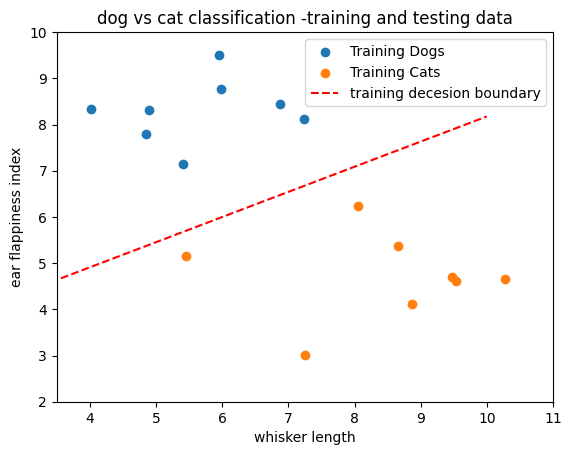

In [87]:
plt.scatter(X_train[y_train == 0] [:,0],X_train[y_train == 0] [:,1], label='Training Dogs')
plt.scatter(X_train[y_train == 1] [:,0],X_train[y_train == 1] [:,1] ,label='Training Cats')
plt.plot(x_vals_train, y_vals_train, color='red', linestyle='--', label='training decesion boundary')
plt.xlim([3.5,11])
plt.ylim([2,10])
plt.xlabel('whisker length')
plt.ylabel('ear flappiness index')  
plt.title('dog vs cat classification -training and testing data')
plt.legend()
plt.show    


In [88]:
print(f"training error:{train_error} ")

training error:0.0 


In [89]:
test_error= compute_error(X_test[y_test==0],X_test[y_test==1],best_theta_train,best_theta0_train)
print(f"testing error:{test_error} ")

testing error:0.0 


<function matplotlib.pyplot.show(close=None, block=None)>

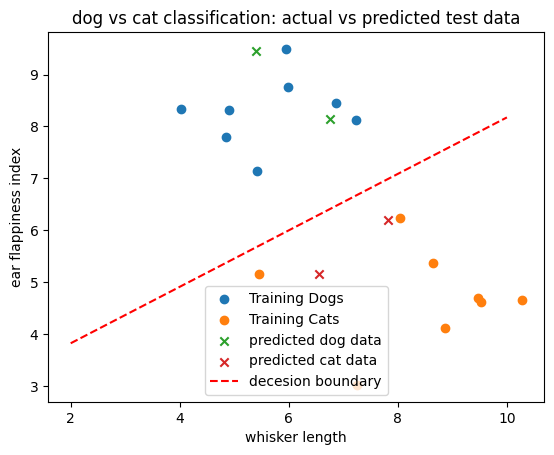

In [90]:
plt.scatter(X_train[y_train == 0] [:,0],X_train[y_train == 0] [:,1], label='Training Dogs')
plt.scatter(X_train[y_train == 1] [:,0],X_train[y_train == 1] [:,1] ,label='Training Cats')

predicted_labels=np.ones_like(y_test)
for i, x_test in enumerate(X_test):
        if np.dot(best_theta_train , x_test) + best_theta0_train > 0:
                predicted_labels[i]= 0

plt.scatter(X_test[predicted_labels==0] [:,0], X_test[predicted_labels==0] [:,1], marker='x', label='predicted dog data')
plt.scatter(X_test[predicted_labels==1] [:,0], X_test[predicted_labels==1] [:,1], marker='x', label='predicted cat data')    

plt.plot(x_vals_train, y_vals_train, color='red', linestyle='--', label='decesion boundary')
plt.xlabel('whisker length')
plt.ylabel('ear flappiness index')  
plt.title('dog vs cat classification: actual vs predicted test data')
plt.legend()
plt.show 